<a href="https://qworld.net" target="_blank" align="left"><img src="../../qworld/images/header.jpg"  align="left"></a>
$ \newcommand{\bra}[1]{\langle #1|} $
$ \newcommand{\ket}[1]{|#1\rangle} $
$ \newcommand{\braket}[2]{\langle #1|#2\rangle} $
$ \newcommand{\dot}[2]{ #1 \cdot #2} $
$ \newcommand{\biginner}[2]{\left\langle #1,#2\right\rangle} $
$ \newcommand{\mymatrix}[2]{\left( \begin{array}{#1} #2\end{array} \right)} $
$ \newcommand{\myvector}[1]{\mymatrix{c}{#1}} $
$ \newcommand{\myrvector}[1]{\mymatrix{r}{#1}} $
$ \newcommand{\mypar}[1]{\left( #1 \right)} $
$ \newcommand{\mybigpar}[1]{ \Big( #1 \Big)} $
$ \newcommand{\sqrttwo}{\frac{1}{\sqrt{2}}} $
$ \newcommand{\dsqrttwo}{\dfrac{1}{\sqrt{2}}} $
$ \newcommand{\onehalf}{\frac{1}{2}} $
$ \newcommand{\donehalf}{\dfrac{1}{2}} $
$ \newcommand{\hadamard}{ \mymatrix{rr}{ \sqrttwo & \sqrttwo \\ \sqrttwo & -\sqrttwo }} $
$ \newcommand{\vzero}{\myvector{1\\0}} $
$ \newcommand{\vone}{\myvector{0\\1}} $
$ \newcommand{\stateplus}{\myvector{ \sqrttwo \\  \sqrttwo } } $
$ \newcommand{\stateminus}{ \myrvector{ \sqrttwo \\ -\sqrttwo } } $
$ \newcommand{\myarray}[2]{ \begin{array}{#1}#2\end{array}} $
$ \newcommand{\X}{ \mymatrix{cc}{0 & 1 \\ 1 & 0}  } $
$ \newcommand{\I}{ \mymatrix{rr}{1 & 0 \\ 0 & 1}  } $
$ \newcommand{\Z}{ \mymatrix{rr}{1 & 0 \\ 0 & -1}  } $
$ \newcommand{\Htwo}{ \mymatrix{rrrr}{ \frac{1}{2} & \frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} & \frac{1}{2} } } $
$ \newcommand{\CNOT}{ \mymatrix{cccc}{1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0} } $
$ \newcommand{\norm}[1]{ \left\lVert #1 \right\rVert } $
$ \newcommand{\pstate}[1]{ \lceil \mspace{-1mu} #1 \mspace{-1.5mu} \rfloor } $
$ \newcommand{\greenbit}[1] {\mathbf{{\color{green}#1}}} $
$ \newcommand{\bluebit}[1] {\mathbf{{\color{blue}#1}}} $
$ \newcommand{\redbit}[1] {\mathbf{{\color{red}#1}}} $
$ \newcommand{\brownbit}[1] {\mathbf{{\color{brown}#1}}} $
$ \newcommand{\blackbit}[1] {\mathbf{{\color{black}#1}}} $

# Solutions - Learning Curves and Ablation Studies

_Prepared by Claudia Zendejas-Morales_

This notebook contains complete solutions for the embedded tasks in notebook `3.5`.

## Common setup

The next cell reproduces the reusable imports and helper functions used in the main notebook. Task-specific analysis helpers are defined with the corresponding solution below.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler

np.set_printoptions(precision=4, suppress=True)

I2 = np.eye(2, dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
CNOT01 = np.array(
    [[1, 0, 0, 0],
     [0, 1, 0, 0],
     [0, 0, 0, 1],
     [0, 0, 1, 0]],
    dtype=complex,
)
Z0 = np.kron(Z, I2)
PSI0 = np.array([1, 0, 0, 0], dtype=complex)


def ry_matrix(theta):
    c = np.cos(theta / 2.0)
    s = np.sin(theta / 2.0)
    return np.array([[c, -s], [s, c]], dtype=complex)


CNOT10 = np.array(
    [[1, 0, 0, 0],
     [0, 0, 0, 1],
     [0, 0, 1, 0],
     [0, 1, 0, 0]],
    dtype=complex,
)

ENCODING_LABELS = {
    'angle_y': 'Angle (RY-RY)',
    'angle_yz': 'Mixed-axis (RY-RZ)',
    'entangled': 'Entangled feature map',
}


def rz_matrix(theta):
    return np.array(
        [[np.exp(-1j * theta / 2.0), 0.0], [0.0, np.exp(1j * theta / 2.0)]],
        dtype=complex,
    )


def feature_state(sample, encoding='angle_y'):
    if encoding == 'angle_y':
        return np.kron(ry_matrix(sample[0]), ry_matrix(sample[1])) @ PSI0
    if encoding == 'angle_yz':
        return np.kron(ry_matrix(sample[0]), rz_matrix(sample[1])) @ PSI0
    if encoding == 'entangled':
        local = np.kron(ry_matrix(sample[0]), ry_matrix(sample[1]))
        cross = np.kron(I2, rz_matrix((sample[0] * sample[1]) / np.pi))
        return CNOT01 @ (cross @ (local @ PSI0))
    raise ValueError("unknown encoding")


def ansatz_unitary(weights, depth):
    U_total = np.eye(4, dtype=complex)
    idx = 0
    for _ in range(depth):
        U_ry = np.kron(ry_matrix(weights[idx]), ry_matrix(weights[idx + 1]))
        idx += 2
        U_rz = np.kron(rz_matrix(weights[idx]), rz_matrix(weights[idx + 1]))
        idx += 2
        U_total = U_rz @ CNOT10 @ U_ry @ CNOT01 @ U_total
    return U_total


def batch_quantum_scores(X, weights, encoding='angle_y', depth=2):
    U_ansatz = ansatz_unitary(weights, depth)
    scores = []
    for sample in X:
        psi = U_ansatz @ feature_state(sample, encoding)
        scores.append(float(np.real(np.vdot(psi, Z0 @ psi))))
    return np.array(scores, dtype=float)


def sample_readout_scores(exact_scores, shots, seed):
    rng = np.random.default_rng(seed)
    probs = np.clip(0.5 * (1.0 + np.asarray(exact_scores, dtype=float)), 0.0, 1.0)
    draws = rng.binomial(int(shots), probs)
    return 2.0 * draws / float(shots) - 1.0


def quantum_probabilities(X, weights, encoding='angle_y', depth=2, shots=None, seed=0, eps=1e-9):
    exact_scores = batch_quantum_scores(X, weights, encoding=encoding, depth=depth)
    used_scores = exact_scores if shots is None else sample_readout_scores(exact_scores, shots=shots, seed=seed)
    return np.clip(0.5 * (1.0 + used_scores), eps, 1.0 - eps)


def mean_binary_cross_entropy(X, y, weights, encoding='angle_y', depth=2, shots=None, seed=0):
    probs = quantum_probabilities(X, weights, encoding=encoding, depth=depth, shots=shots, seed=seed)
    y = np.asarray(y, dtype=float)
    return float(np.mean(-y * np.log(probs) - (1.0 - y) * np.log(1.0 - probs)))


def parameter_shift_gradient_bce(X, y, weights, encoding='angle_y', depth=2, shots=None, seed=0):
    gradient = np.zeros_like(weights, dtype=float)
    shift = np.pi / 2.0
    rng = np.random.default_rng(seed)
    for m in range(len(weights)):
        weights_plus = weights.copy()
        weights_minus = weights.copy()
        weights_plus[m] += shift
        weights_minus[m] -= shift
        if shots is None:
            loss_plus = mean_binary_cross_entropy(X, y, weights_plus, encoding=encoding, depth=depth)
            loss_minus = mean_binary_cross_entropy(X, y, weights_minus, encoding=encoding, depth=depth)
        else:
            seed_plus = int(rng.integers(0, 1_000_000_000))
            seed_minus = int(rng.integers(0, 1_000_000_000))
            loss_plus = mean_binary_cross_entropy(X, y, weights_plus, encoding=encoding, depth=depth, shots=shots, seed=seed_plus)
            loss_minus = mean_binary_cross_entropy(X, y, weights_minus, encoding=encoding, depth=depth, shots=shots, seed=seed_minus)
        gradient[m] = 0.5 * (loss_plus - loss_minus)
    return gradient


def train_quantum_classifier(X_train, y_train, X_val, y_val, *, encoding='angle_y', depth=2, shots=None, epochs=14, lr=0.08, seed=0):
    rng = np.random.default_rng(seed)
    weights = rng.normal(scale=0.35, size=4 * depth)
    first_moment = np.zeros_like(weights)
    second_moment = np.zeros_like(weights)
    beta1, beta2 = 0.9, 0.999
    history = {'train_loss': [], 'val_loss': []}
    best_weights = weights.copy()
    best_val_loss = mean_binary_cross_entropy(X_val, y_val, weights, encoding=encoding, depth=depth)
    for epoch in range(1, epochs + 1):
        grad_seed = int(rng.integers(0, 1_000_000_000))
        gradient = parameter_shift_gradient_bce(X_train, y_train, weights, encoding=encoding, depth=depth, shots=shots, seed=grad_seed)
        first_moment = beta1 * first_moment + (1.0 - beta1) * gradient
        second_moment = beta2 * second_moment + (1.0 - beta2) * (gradient ** 2)
        m_hat = first_moment / (1.0 - beta1 ** epoch)
        v_hat = second_moment / (1.0 - beta2 ** epoch)
        weights = weights - lr * m_hat / (np.sqrt(v_hat) + 1e-8)
        train_loss = mean_binary_cross_entropy(X_train, y_train, weights, encoding=encoding, depth=depth)
        val_loss = mean_binary_cross_entropy(X_val, y_val, weights, encoding=encoding, depth=depth)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = weights.copy()
    return {'weights': best_weights, 'history': history, 'best_val_loss': float(best_val_loss)}


def quantum_predict_labels(X, weights, encoding='angle_y', depth=2, shots=None, seed=0):
    return (quantum_probabilities(X, weights, encoding=encoding, depth=depth, shots=shots, seed=seed) >= 0.5).astype(int)



def prepare_breast_cancer_representation(split_seed=11, subset_size=None, subset_seed=0):
    data = load_breast_cancer()
    X = data.data
    y = data.target.astype(int)
    X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.20, random_state=split_seed, stratify=y)
    X_train_pool, X_val, y_train_pool, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=split_seed, stratify=y_train_val)
    if subset_size is not None and subset_size < len(X_train_pool):
        X_train, _, y_train, _ = train_test_split(X_train_pool, y_train_pool, train_size=int(subset_size), random_state=subset_seed, stratify=y_train_pool)
    else:
        X_train = X_train_pool.copy()
        y_train = y_train_pool.copy()
    scaler = StandardScaler().fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    pca = PCA(n_components=2, random_state=split_seed).fit(X_train_scaled)
    X_train_pca = pca.transform(X_train_scaled)
    X_val_pca = pca.transform(X_val_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    angle_scaler = MinMaxScaler(feature_range=(0.0, np.pi)).fit(X_train_pca)
    return {
        'X_train': angle_scaler.transform(X_train_pca),
        'X_val': angle_scaler.transform(X_val_pca),
        'X_test': angle_scaler.transform(X_test_pca),
        'y_train': y_train,
        'y_val': y_val,
        'y_test': y_test,
        'train_size': len(y_train),
        'explained_variance_ratio': pca.explained_variance_ratio_,
    }


def fit_and_evaluate_model(data_dict, model_spec, seed):
    X_train, X_val, X_test = data_dict['X_train'], data_dict['X_val'], data_dict['X_test']
    y_train, y_val, y_test = data_dict['y_train'], data_dict['y_val'], data_dict['y_test']
    train_size = data_dict['train_size']
    if model_spec['kind'] == 'qml':
        result = train_quantum_classifier(X_train, y_train, X_val, y_val, encoding=model_spec['encoding'], depth=model_spec['depth'], shots=model_spec.get('shots'), epochs=model_spec.get('epochs', 14), lr=model_spec.get('lr', 0.08), seed=seed)
        weights = result['weights']
        preds_train = quantum_predict_labels(X_train, weights, encoding=model_spec['encoding'], depth=model_spec['depth'])
        preds_val = quantum_predict_labels(X_val, weights, encoding=model_spec['encoding'], depth=model_spec['depth'])
        preds_test = quantum_predict_labels(X_test, weights, encoding=model_spec['encoding'], depth=model_spec['depth'])
    else:
        estimator = clone(model_spec['estimator'])
        if hasattr(estimator, 'random_state'):
            estimator.set_params(random_state=seed)
        estimator.fit(X_train, y_train)
        preds_train = estimator.predict(X_train)
        preds_val = estimator.predict(X_val)
        preds_test = estimator.predict(X_test)
    return [
        {'model': model_spec['name'], 'split': 'train', 'train_size': int(train_size), 'seed': int(seed), 'accuracy': float(accuracy_score(y_train, preds_train)), 'f1': float(f1_score(y_train, preds_train))},
        {'model': model_spec['name'], 'split': 'validation', 'train_size': int(train_size), 'seed': int(seed), 'accuracy': float(accuracy_score(y_val, preds_val)), 'f1': float(f1_score(y_val, preds_val))},
        {'model': model_spec['name'], 'split': 'test', 'train_size': int(train_size), 'seed': int(seed), 'accuracy': float(accuracy_score(y_test, preds_test)), 'f1': float(f1_score(y_test, preds_test))},
    ]


def run_learning_curve_study(train_sizes, seeds, model_specs, split_seed=11):
    rows = []
    for train_size in train_sizes:
        for seed in seeds:
            data_dict = prepare_breast_cancer_representation(split_seed=split_seed, subset_size=train_size, subset_seed=seed)
            for model_spec in model_specs:
                rows.extend(fit_and_evaluate_model(data_dict, model_spec, seed=seed))
    return rows


def summarize_curve_rows(rows, metric='f1'):
    summary = []
    keys = sorted({(row['model'], row['split'], row['train_size']) for row in rows})
    for model_name, split_name, train_size in keys:
        values = np.array([row[metric] for row in rows if row['model'] == model_name and row['split'] == split_name and row['train_size'] == train_size], dtype=float)
        summary.append({'model': model_name, 'split': split_name, 'train_size': train_size, 'mean': float(values.mean()), 'std': float(values.std(ddof=1)) if len(values) > 1 else 0.0})
    return summary


def plot_learning_curve_summary(summary_rows, model_order, metric_label='F1 score'):
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), sharey=True)
    for ax, (split_name, title) in zip(axes, [('train', 'Training'), ('validation', 'Validation')]):
        for model_name in model_order:
            subset = sorted([row for row in summary_rows if row['model'] == model_name and row['split'] == split_name], key=lambda row: row['train_size'])
            ax.errorbar([row['train_size'] for row in subset], [row['mean'] for row in subset], yerr=[row['std'] for row in subset], marker='o', linewidth=2.0, capsize=4, label=model_name)
        ax.set_xlabel('Training-set size')
        ax.set_ylabel(metric_label)
        ax.set_title(f'{title} curve')
        ax.grid(alpha=0.22)
    axes[1].legend(frameon=False, bbox_to_anchor=(1.02, 1.0), loc='upper left')
    fig.tight_layout()
    plt.show()



def run_qml_configuration(data_dict, encoding, depth, shots, seed, epochs=12, lr=0.08):
    result = train_quantum_classifier(data_dict['X_train'], data_dict['y_train'], data_dict['X_val'], data_dict['y_val'], encoding=encoding, depth=depth, shots=shots, epochs=epochs, lr=lr, seed=seed)
    weights = result['weights']
    return {
        'encoding': encoding,
        'depth': int(depth),
        'shots': shots,
        'seed': int(seed),
        'train_f1': float(f1_score(data_dict['y_train'], quantum_predict_labels(data_dict['X_train'], weights, encoding=encoding, depth=depth))),
        'validation_f1': float(f1_score(data_dict['y_val'], quantum_predict_labels(data_dict['X_val'], weights, encoding=encoding, depth=depth))),
        'test_f1': float(f1_score(data_dict['y_test'], quantum_predict_labels(data_dict['X_test'], weights, encoding=encoding, depth=depth))),
        'best_val_loss': result['best_val_loss'],
    }


def run_ablation_grid(data_dict, encodings, depths, shot_values, seeds, epochs=12, lr=0.08):
    rows = []
    for encoding in encodings:
        for depth in depths:
            for shots in shot_values:
                for seed in seeds:
                    rows.append(run_qml_configuration(data_dict, encoding=encoding, depth=depth, shots=shots, seed=seed, epochs=epochs, lr=lr))
    return rows


def summarize_ablation_rows(rows, split='validation', metric='f1'):
    key_metric = f'{split}_{metric}'
    summary = []
    keys = sorted({(row['encoding'], row['depth'], row['shots']) for row in rows}, key=lambda item: (item[0], item[1], -1 if item[2] is None else item[2]))
    for encoding, depth, shots in keys:
        values = np.array([row[key_metric] for row in rows if row['encoding'] == encoding and row['depth'] == depth and row['shots'] == shots], dtype=float)
        summary.append({'encoding': encoding, 'depth': depth, 'shots': shots, 'mean': float(values.mean()), 'std': float(values.std(ddof=1)) if len(values) > 1 else 0.0})
    return summary


def shots_label(shots):
    return 'exact' if shots is None else str(shots)


def print_ablation_table(summary_rows, mean_label='mean score'):
    header = f"{'encoding':<24} {'depth':>7} {'shots':>8} {mean_label:>14} {'std':>10}"
    print(header)
    print('-' * len(header))
    for row in summary_rows:
        print(f"{ENCODING_LABELS[row['encoding']]:<24} {row['depth']:>7} {shots_label(row['shots']):>8} {row['mean']:>14.4f} {row['std']:>10.4f}")


def plot_ablation_panels(summary_rows, encodings, depths, shot_values, title, cmap='YlGnBu'):
    fig, axes = plt.subplots(1, len(shot_values), figsize=(4.4 * len(shot_values), 4.0), squeeze=False)
    axes = axes[0]
    all_means = [row['mean'] for row in summary_rows]
    vmin, vmax = min(all_means), max(all_means)
    for ax, shots in zip(axes, shot_values):
        grid = np.zeros((len(encodings), len(depths)))
        for i, encoding in enumerate(encodings):
            for j, depth in enumerate(depths):
                row = next(row for row in summary_rows if row['encoding'] == encoding and row['depth'] == depth and row['shots'] == shots)
                grid[i, j] = row['mean']
        im = ax.imshow(grid, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
        ax.set_title(f'shots = {shots_label(shots)}')
        ax.set_xticks(range(len(depths)))
        ax.set_xticklabels(depths)
        ax.set_yticks(range(len(encodings)))
        ax.set_yticklabels([ENCODING_LABELS[e] for e in encodings])
        ax.set_xlabel('Depth')
        for i in range(len(encodings)):
            for j in range(len(depths)):
                ax.text(j, i, f'{grid[i, j]:.3f}', ha='center', va='center', color='black', fontsize=10)
    axes[0].set_ylabel('Encoding')
    fig.suptitle(title)
    fig.subplots_adjust(left=0.08, right=0.90, bottom=0.14, top=0.82, wspace=0.32)
    cbar = fig.colorbar(im, ax=axes, fraction=0.032, pad=0.02)
    cbar.ax.set_ylabel('Mean validation F1', rotation=90)
    plt.show()


def plot_mean_std_tradeoff(summary_rows):
    encoding_colors = {
        'angle_y': '#d98500',
        'angle_yz': '#2f6fed',
        'entangled': '#2d8a66',
    }
    depth_markers = {1: 'o', 2: 's', 3: 'D'}
    shot_sizes = {None: 130, 128: 95, 512: 70}

    fig, ax = plt.subplots(figsize=(8.8, 5.2))
    for row in summary_rows:
        x, y = row['std'], row['mean']
        color = encoding_colors[row['encoding']]
        marker = depth_markers[row['depth']]
        size = shot_sizes.get(row['shots'], 85)
        if row['shots'] is None:
            ax.scatter(x, y, s=size, marker=marker, facecolors='none', edgecolors=color, linewidths=2.0, alpha=0.95)
        else:
            ax.scatter(x, y, s=size, marker=marker, c=color, edgecolors='black', linewidths=0.45, alpha=0.88)
    ax.set_xlabel('Standard deviation of test F1')
    ax.set_ylabel('Mean test F1')
    ax.set_title('Mean-variability trade-off across ablation configurations')
    ax.grid(alpha=0.25)

    encoding_handles = [
        plt.Line2D([0], [0], marker='o', linestyle='None', markerfacecolor=color, markeredgecolor=color, markersize=8, label=ENCODING_LABELS[key])
        for key, color in encoding_colors.items()
    ]
    depth_handles = [
        plt.Line2D([0], [0], marker=marker, linestyle='None', markerfacecolor='#777777', markeredgecolor='#222222', markersize=8, label=f'depth {depth}')
        for depth, marker in depth_markers.items()
    ]
    shot_handles = [
        plt.Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='none' if shots is None else '#777777', markeredgecolor='#444444', markersize=size ** 0.5 / 1.4, label=f'shots = {shots_label(shots)}')
        for shots, size in shot_sizes.items()
    ]

    leg1 = ax.legend(handles=encoding_handles, title='Encoding', frameon=False, loc='upper left', bbox_to_anchor=(1.02, 1.00))
    ax.add_artist(leg1)
    leg2 = ax.legend(handles=depth_handles, title='Depth', frameon=False, loc='upper left', bbox_to_anchor=(1.02, 0.63))
    ax.add_artist(leg2)
    ax.legend(handles=shot_handles, title='Shot budget', frameon=False, loc='upper left', bbox_to_anchor=(1.02, 0.28))
    fig.subplots_adjust(left=0.10, right=0.76, bottom=0.14, top=0.90)
    plt.show()


<a id="task1-solution"></a>

## Task 1 (coding): One complete solution

We compare two QML encodings against a matched classical baseline and turn the validation curves into an explicit sample-efficiency comparison.


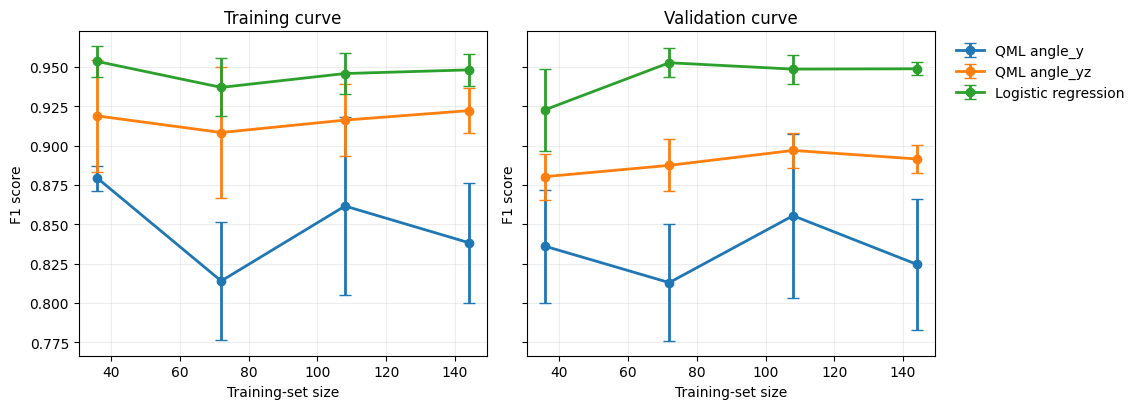

Normalized area under the mean validation learning curve:
{'QML angle_y': 0.8328406671179672, 'QML angle_yz': 0.8900607582980574, 'Logistic regression': 0.9456748298811938}

Validation-F1 gap to logistic regression:
{'train_size': 36, 'qml_model': 'QML angle_y', 'gap_to_logistic': 0.0868869148582081}
{'train_size': 36, 'qml_model': 'QML angle_yz', 'gap_to_logistic': 0.04257901911954676}
{'train_size': 72, 'qml_model': 'QML angle_y', 'gap_to_logistic': 0.13973473070292952}
{'train_size': 72, 'qml_model': 'QML angle_yz', 'gap_to_logistic': 0.06521824913000296}
{'train_size': 108, 'qml_model': 'QML angle_y', 'gap_to_logistic': 0.09316523429153323}
{'train_size': 108, 'qml_model': 'QML angle_yz', 'gap_to_logistic': 0.051675775528090995}
{'train_size': 144, 'qml_model': 'QML angle_y', 'gap_to_logistic': 0.12431813173222617}
{'train_size': 144, 'qml_model': 'QML angle_yz', 'gap_to_logistic': 0.05731736106308527}


In [2]:
def validation_curve_area(summary_rows, model_name):
    subset = sorted(
        [row for row in summary_rows if row['model'] == model_name and row['split'] == 'validation'],
        key=lambda row: row['train_size'],
    )
    xs = np.array([row['train_size'] for row in subset], dtype=float)
    ys = np.array([row['mean'] for row in subset], dtype=float)
    trapezoid_area = np.sum(0.5 * (ys[1:] + ys[:-1]) * (xs[1:] - xs[:-1]))
    return float(trapezoid_area / (xs[-1] - xs[0]))


def qml_gap_rows(summary_rows, qml_names, baseline_name='Logistic regression'):
    gaps = []
    train_sizes = sorted({row['train_size'] for row in summary_rows if row['split'] == 'validation'})
    for train_size in train_sizes:
        baseline_row = next(
            row for row in summary_rows
            if row['model'] == baseline_name and row['split'] == 'validation' and row['train_size'] == train_size
        )
        for qml_name in qml_names:
            qml_row = next(
                row for row in summary_rows
                if row['model'] == qml_name and row['split'] == 'validation' and row['train_size'] == train_size
            )
            gaps.append({
                'train_size': train_size,
                'qml_model': qml_name,
                'gap_to_logistic': float(baseline_row['mean'] - qml_row['mean']),
            })
    return gaps


train_sizes_task1 = [36, 72, 108, 144]
seeds_task1 = [0, 1, 2, 3]
model_specs_task1 = [
    {'name': 'QML angle_y', 'kind': 'qml', 'encoding': 'angle_y', 'depth': 2, 'shots': None, 'epochs': 12, 'lr': 0.08},
    {'name': 'QML angle_yz', 'kind': 'qml', 'encoding': 'angle_yz', 'depth': 2, 'shots': None, 'epochs': 12, 'lr': 0.08},
    {'name': 'Logistic regression', 'kind': 'classical', 'estimator': LogisticRegression(max_iter=4000)},
]
rows_task1 = run_learning_curve_study(train_sizes_task1, seeds_task1, model_specs_task1, split_seed=11)
summary_task1 = summarize_curve_rows(rows_task1, metric='f1')
plot_learning_curve_summary(summary_task1, model_order=['QML angle_y', 'QML angle_yz', 'Logistic regression'])

areas_task1 = {
    name: validation_curve_area(summary_task1, name)
    for name in ['QML angle_y', 'QML angle_yz', 'Logistic regression']
}
print('Normalized area under the mean validation learning curve:')
print(areas_task1)

print('\nValidation-F1 gap to logistic regression:')
for row in qml_gap_rows(summary_task1, ['QML angle_y', 'QML angle_yz']):
    print(row)


The validation-curve areas make the QML comparison more explicit. In this run, `QML angle_yz` has a clearly larger area than `QML angle_y`, so the encoding change improves sample efficiency within the QML family across the tested training-size range. However, both QML variants remain below logistic regression, whose area is still the largest of the three.

The per-size gaps give the same conclusion in a more local way. At every tested training size, the `QML angle_yz` gap to logistic regression is smaller than the `QML angle_y` gap, so the richer encoding consistently narrows the classical gap. That is already a meaningful QML conclusion: even when the quantum model does not yet overtake the matched classical baseline, the learning-curve comparison can still show that one QML design choice is systematically better than another under the same evaluation protocol.


<a id="task2-solution"></a>

## Task 2 (coding): One complete solution

We add the exact-training reference, compute finite-shot penalties, and then use a shot-sensitivity metric to identify which configurations are more robust to shot noise.


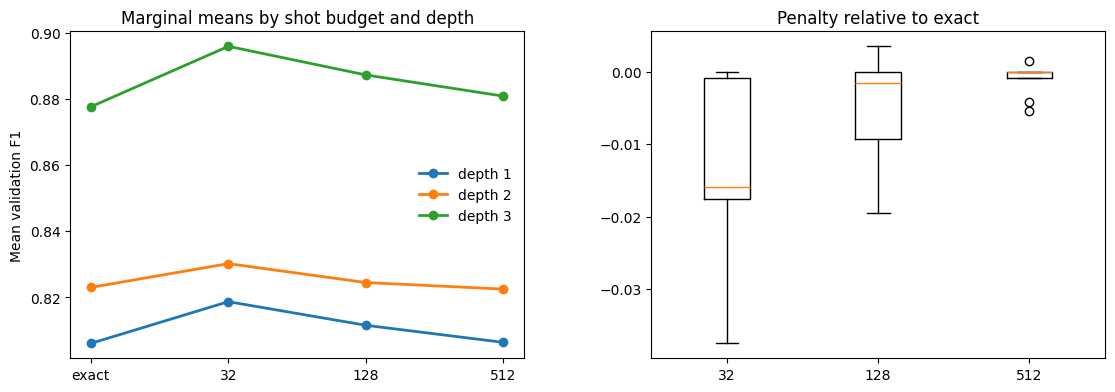

Sorted by shot sensitivity (smaller mean_abs_penalty = more robust):
{'encoding': 'angle_yz', 'depth': 1, 'mean_abs_penalty': 0.0, 'max_abs_penalty': 0.0}
{'encoding': 'entangled', 'depth': 2, 'mean_abs_penalty': 0.0007933269867174871, 'max_abs_penalty': 0.0015235022628490302}
{'encoding': 'angle_y', 'depth': 1, 'mean_abs_penalty': 0.000953389051481938, 'max_abs_penalty': 0.001559454191033205}
{'encoding': 'angle_yz', 'depth': 2, 'mean_abs_penalty': 0.002210004941384273, 'max_abs_penalty': 0.0034815292106609164}
{'encoding': 'angle_y', 'depth': 3, 'mean_abs_penalty': 0.0075228602773975695, 'max_abs_penalty': 0.02249757831256627}
{'encoding': 'angle_y', 'depth': 2, 'mean_abs_penalty': 0.008503560407811936, 'max_abs_penalty': 0.017589451125845534}
{'encoding': 'angle_yz', 'depth': 3, 'mean_abs_penalty': 0.009798717310102586, 'max_abs_penalty': 0.015928245468970204}
{'encoding': 'entangled', 'depth': 3, 'mean_abs_penalty': 0.013826880652486237, 'max_abs_penalty': 0.019557811370838785}
{'e

In [3]:
def compute_shot_penalty_rows(summary_rows):
    penalties = []
    for row in [row for row in summary_rows if row['shots'] is not None]:
        exact_row = next(ref for ref in summary_rows if ref['encoding'] == row['encoding'] and ref['depth'] == row['depth'] and ref['shots'] is None)
        penalties.append({'encoding': row['encoding'], 'depth': row['depth'], 'shots': row['shots'], 'penalty': exact_row['mean'] - row['mean']})
    return penalties


def shot_sensitivity_table(penalty_rows):
    summary = []
    keys = sorted({(row['encoding'], row['depth']) for row in penalty_rows}, key=lambda item: (item[0], item[1]))
    for encoding, depth in keys:
        values = np.array([abs(row['penalty']) for row in penalty_rows if row['encoding'] == encoding and row['depth'] == depth], dtype=float)
        summary.append({
            'encoding': encoding,
            'depth': depth,
            'mean_abs_penalty': float(values.mean()),
            'max_abs_penalty': float(values.max()),
        })
    return sorted(summary, key=lambda row: row['mean_abs_penalty'])


data_task2 = prepare_breast_cancer_representation(split_seed=11)
rows_task2 = run_ablation_grid(data_task2, encodings=['angle_y', 'angle_yz', 'entangled'], depths=[1, 2, 3], shot_values=[None, 32, 128, 512], seeds=[0, 1, 2], epochs=10, lr=0.08)
summary_task2 = summarize_ablation_rows(rows_task2, split='validation', metric='f1')
penalty_rows = compute_shot_penalty_rows(summary_task2)
sensitivity_rows = shot_sensitivity_table(penalty_rows)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))
for depth in [1, 2, 3]:
    subset = []
    for shots in [None, 32, 128, 512]:
        rows_here = [row['mean'] for row in summary_task2 if row['depth'] == depth and row['shots'] == shots]
        subset.append(float(np.mean(rows_here)))
    axes[0].plot(range(4), subset, marker='o', linewidth=2.0, label=f'depth {depth}')
axes[0].set_xticks(range(4))
axes[0].set_xticklabels([shots_label(s) for s in [None, 32, 128, 512]])
axes[0].legend(frameon=False)
axes[0].set_ylabel('Mean validation F1')
axes[0].set_title('Marginal means by shot budget and depth')
penalty_groups = [[row['penalty'] for row in penalty_rows if row['shots'] == shots] for shots in [32, 128, 512]]
axes[1].boxplot(penalty_groups, tick_labels=['32', '128', '512'])
axes[1].set_title('Penalty relative to exact')
fig.subplots_adjust(left=0.08, right=0.98, bottom=0.14, top=0.90, wspace=0.28)
plt.show()

print('Sorted by shot sensitivity (smaller mean_abs_penalty = more robust):')
for row in sensitivity_rows:
    print(row)


The boxplots summarize the overall shot effect across the grid: smaller shot budgets tend to produce larger negative penalties relative to exact training, while larger shot budgets remain closer to zero. The printed sensitivity table then refines that picture at the level of individual configurations. Here, the expression sensitivity table refers to the sorted list of `(encoding, depth)` pairs together with their `mean_abs_penalty` and `max_abs_penalty`, where `mean_abs_penalty` measures the average absolute deviation from the exact-training reference across the tested finite shot budgets.

Under that metric, the most robust configurations are the ones whose finite-shot penalties stay closest to zero across the tested shot budgets, while the least robust ones are those whose penalties drift farther from the exact reference. In this run, the mixed-axis `angle_yz` encoding at low depth is among the most robust options, whereas some entangled or deeper configurations are more sensitive to finite-shot training. That is a useful QML conclusion because it connects robustness not only to the shot budget itself, but also to the model design. The strongest validation configuration and the most shot-robust configuration do not have to be the same, so the task helps separate two different claims: high performance under one resource setting and stability under changing measurement resources.


<a id="task3-solution"></a>

## Task 3 (coding): One complete solution

We summarize repeated ablation results, extract the Pareto-efficient configurations, and compare them with the validation winner.

encoding                   depth    shots   mean test F1        std
-------------------------------------------------------------------
Entangled feature map          1      128         0.8974     0.0117
Entangled feature map          1      512         0.8894     0.0162
Entangled feature map          1    exact         0.8883     0.0154
Entangled feature map          3      128         0.8805     0.0146
Entangled feature map          3      512         0.8767     0.0109
Mixed-axis (RY-RZ)             2      128         0.8761     0.0256
Entangled feature map          3    exact         0.8745     0.0091
Angle (RY-RY)                  3      128         0.8743     0.0151
Mixed-axis (RY-RZ)             3      128         0.8743     0.0145
Mixed-axis (RY-RZ)             2      512         0.8737     0.0224
Mixed-axis (RY-RZ)             3    exact         0.8725     0.0159
Angle (RY-RY)                  3      512         0.8721     0.0117
Mixed-axis (RY-RZ)             2    exact       

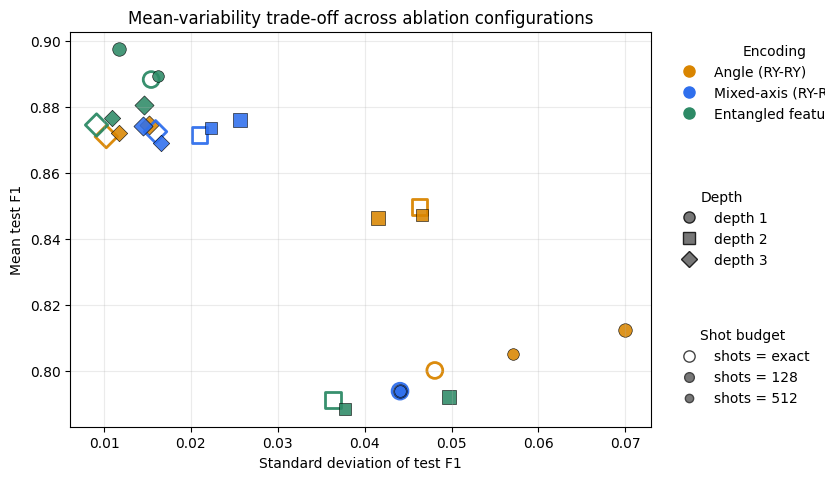

Validation winner: {'encoding': 'entangled', 'depth': 3, 'shots': 128, 'mean': 0.8900801523440446, 'std': 0.024795129464419433}
Pareto-efficient configurations: [{'encoding': 'entangled', 'depth': 1, 'shots': 128, 'mean': 0.8973586508287082, 'std': 0.01172875041694903}, {'encoding': 'entangled', 'depth': 3, 'shots': None, 'mean': 0.8744968606300239, 'std': 0.009137590365809573}, {'encoding': 'entangled', 'depth': 3, 'shots': 512, 'mean': 0.8766887259722346, 'std': 0.010947240440507872}]


In [4]:
def pareto_efficient_configs(summary_rows):
    frontier = []
    for row in summary_rows:
        dominated = False
        for other in summary_rows:
            better_mean = other['mean'] >= row['mean']
            better_std = other['std'] <= row['std']
            better_somewhere = other['mean'] > row['mean'] or other['std'] < row['std']
            if better_mean and better_std and better_somewhere:
                dominated = True
                break
        if not dominated:
            frontier.append(row)
    return frontier


data_task3 = prepare_breast_cancer_representation(split_seed=11)
rows_task3 = run_ablation_grid(data_task3, encodings=['angle_y', 'angle_yz', 'entangled'], depths=[1, 2, 3], shot_values=[None, 128, 512], seeds=[0, 1, 2, 3, 4], epochs=10, lr=0.08)
validation_summary = summarize_ablation_rows(rows_task3, split='validation', metric='f1')
test_summary = summarize_ablation_rows(rows_task3, split='test', metric='f1')
frontier = pareto_efficient_configs(test_summary)
validation_winner = max(validation_summary, key=lambda row: row['mean'])

test_summary_sorted = sorted(test_summary, key=lambda row: (-row['mean'], row['std']))
print_ablation_table(test_summary_sorted, mean_label='mean test F1')
plot_mean_std_tradeoff(test_summary)
print('Validation winner:', validation_winner)
print('Pareto-efficient configurations:', frontier)


The table should be read together with the scatter plot. The identity of each configuration is recovered from the legends and from the printed summary table rather than from text labels placed on top of the points. The table gives the exact tuples `(encoding, depth, shots)`, while the plot shows the geometry of the mean-variability trade-off.

The validation winner and the Pareto-efficient set do not answer the same question. The validation winner is the single configuration with the highest mean validation F1, while the Pareto set collects all test configurations for which no other one is simultaneously better in mean test F1 and smaller in variability. A configuration can therefore belong to the Pareto frontier without being the validation winner, and the printed frontier makes that distinction explicit without overloading the figure.
